# Testing Data Retrieval and Database Building from WQP
Using WQP's webservice APIs

Not usable, not enough data.

In [1]:
# %pip -q install pandas

In [1]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.waterqualitydata.us/data/Result/search"
# bbox = "-88.7,41.3,-84.4,46.4"  # lake michigan rough bounding box
# bbox = "-82.36,27.84,-82.25,27.89"  # riverview, FL (alafia river)
# bbox = "-95.55,29.73,-95.28,29.78"  # houston, TX
# bbox = "-87.75,41.86,-87.58,41.95"
bbox = "-96.10,36.05,-95.80,36.25"

params = [
    # ("countrycode", "LE"),
    ("bBox", bbox),
    ("dataProfile", "biological"),
    ("providers", "NWIS"),
    ("providers", "STORET"),
    ("mimeType", "csv"),
    ("zip", "no"),
    ("startDateLo", "01-01-2012"),
    ("startDateHi", "12-31-2022"),
]

r = requests.get(url, params=params, timeout=180)
print("STATUS:", r.status_code)
print("URL:", r.url)
print("Warning:", r.headers.get("Warning"))
print("BODY preview:", r.text[:300])

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))
df.head()


STATUS: 200
URL: https://www.waterqualitydata.us/data/Result/search?bBox=-96.10%2C36.05%2C-95.80%2C36.25&dataProfile=biological&providers=NWIS&providers=STORET&mimeType=csv&zip=no&startDateLo=01-01-2012&startDateHi=12-31-2022
BODY preview: OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,ActivityEndTime/Time,ActivityEndTime/TimeZoneCode,ActivityRelativeDepthName,Activit


C:\Users\kcui2\AppData\Local\Temp\ipykernel_45728\2060960690.py:31: DtypeWarning: Columns (32,33,60,125) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(r.text))


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,...,LabSamplePreparationMethod/MethodQualifierTypeName,LabSamplePreparationMethod/MethodDescriptionText,PreparationStartDate,PreparationStartTime/Time,PreparationStartTime/TimeZoneCode,PreparationEndDate,PreparationEndTime/Time,PreparationEndTime/TimeZoneCode,SubstitutionDilutionFactorNumeric,ProviderName
0,OKWRB-STREAMS_WQX,OWRB Streams Monitoring,OKWRB-STREAMS_WQX-HD-25372.208,Quality Control Sample-Lab Duplicate,Water,Surface Water,2013-02-11,14:05:00,CST,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
1,OKWRB-STREAMS_WQX,OWRB Streams Monitoring,OKWRB-STREAMS_WQX-HD-37048.205,Sample-Other,Water,Surface Water,2013-11-18,11:50:00,CST,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
2,OKWRB-STREAMS_WQX,OWRB Streams Monitoring,OKWRB-STREAMS_WQX-HD-529209,Quality Control Sample-Field Replicate,Water,Surface Water,2013-05-20,13:39:00,CDT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
3,OKWRB-STREAMS_WQX,OWRB Streams Monitoring,OKWRB-STREAMS_WQX-HD-24150.204,Sample-Other,Water,Surface Water,2013-01-07,14:15:00,CST,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
4,OKWRB-STREAMS_WQX,OWRB Streams Monitoring,OKWRB-STREAMS_WQX-HD-28805.205,Sample-Other,Water,Surface Water,2013-05-20,13:34:00,CDT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET


In [2]:
df.shape

(7253, 156)

Note: Chicago's bounding box seems to have very little data.

## Core Columns for Trend Analysis

### Time Axis (Mandatory)
- `ActivityStartDate`
- `ActivityStartTime/Time`
- `ActivityEndDate`
- `ActivityEndTime/Time`

### Location Axis (Mandatory)
- `MonitoringLocationIdentifier`

### Location Context
- `ActivityDepthHeightMeasure/MeasureValue`
- `ActivityMediaName`

### Measurement Axis (Mandatory)
- `CharacteristicName`
- `ResultMeasureValue`
- `ResultMeasure/MeasureUnitCode`

---

## Quality Control Columns
- `ResultStatusIdentifier`
- `MeasureQualifierCode`
- `DetectionQuantitationLimitMeasure/MeasureValue`
- `ResultDetectionConditionText`

---

## Optional but Useful Columns
- `ProjectIdentifier`
- `ResultAnalyticalMethod/MethodName`
- `DataProvider`
- `ActivityDepthHeightMeasure/MeasureUnitCode`


Other potential columns:
- `ResultSampleFractionText`
- `ResultStatusIdentifier`
- `ResultAnalyticalMethod/MethodIdentifier`
- `ResultAnalyticalMethod/MethodIdentifierContext`
- `ResultAnalyticalMethod/MethodName`

- `AnalysisStartDate`
- `LastUpdated`

In [3]:
# filter only necessary columns
columns_to_keep = [
    "ActivityStartDate",
    "ActivityStartTime/Time",
    "ActivityEndDate",
    "ActivityEndTime/Time",
    "MonitoringLocationIdentifier",
    "ActivityDepthHeightMeasure/MeasureValue",
    "ActivityMediaName",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode",
    "ResultStatusIdentifier",
    "MeasureQualifierCode",
    "DetectionQuantitationLimitMeasure/MeasureValue",
    "ResultDetectionConditionText",
    "ProjectIdentifier",
    "ResultAnalyticalMethod/MethodName",
    "ProviderName",
    "ActivityDepthHeightMeasure/MeasureUnitCode",
]

df_target = df[columns_to_keep]
df_target.head(10), df_target.shape


(  ActivityStartDate ActivityStartTime/Time  ActivityEndDate  \
 0        2013-02-11               14:05:00              NaN   
 1        2013-11-18               11:50:00              NaN   
 2        2013-05-20               13:39:00              NaN   
 3        2013-01-07               14:15:00              NaN   
 4        2013-05-20               13:34:00              NaN   
 5        2013-02-11               14:00:00              NaN   
 6        2013-04-01               15:00:00              NaN   
 7        2013-07-29               13:33:00              NaN   
 8        2013-06-24               12:46:00              NaN   
 9        2013-02-11               14:05:00              NaN   
 
    ActivityEndTime/Time          MonitoringLocationIdentifier  \
 0                   NaN  OKWRB-STREAMS_WQX-121300010010-001AT   
 1                   NaN  OKWRB-STREAMS_WQX-121300010010-001AT   
 2                   NaN  OKWRB-STREAMS_WQX-121300010010-001AT   
 3                   NaN  OKWR

In [5]:
# %pip install matplotlib

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# visualizations for multiple characteristics
def plot_wqp_characteristic_trends(
    df: pd.DataFrame,
    characteristics,
    date_col: str = "ActivityStartDate",
    char_col: str = "CharacteristicName",
    value_col: str = "ResultMeasureValue",
    unit_col: str = "ResultMeasure/MeasureUnitCode",
    only_accepted: bool = False,
    status_col: str = "ResultStatusIdentifier",
    choose_unit: str = "most_common",   # "most_common" or a specific unit string
    showfliers: bool = False,
    point_size: int = 8
):
    """
    For each characteristic in `characteristics`, plots:
      A) raw scatter over time
      B) monthly mean trend
      C) monthly boxplots (distribution by month)

    Notes:
      - Drops rows with missing date/characteristic/value
      - Coerces date/value types
      - Optionally filters to accepted results
      - If multiple units exist, can pick the most common unit to avoid mixing
    """
    # Normalize characteristics input
    if isinstance(characteristics, str):
        characteristics = [characteristics]

    data = df.copy()

    # Basic cleaning
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    if only_accepted and status_col in data.columns:
        data = data[data[status_col].astype(str).str.lower().eq("accepted")]

    # Drop rows missing critical fields
    data = data.dropna(subset=[date_col, char_col, value_col])

    print("num rows after cleaning:", len(data))
    print("unique characteristics:", data[char_col].nunique())

    for char in characteristics:
        dchar = data[data[char_col] == char].copy()

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after filtering).")
            continue

        # Unit handling
        unit = None
        if unit_col in dchar.columns:
            if choose_unit == "most_common":
                unit = dchar[unit_col].dropna().value_counts().index[0] if dchar[unit_col].notna().any() else None
                if unit is not None:
                    dchar = dchar[dchar[unit_col] == unit]
            else: 
                unit = choose_unit
                dchar = dchar[dchar[unit_col] == unit]

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after unit filter).")
            continue

        print("Plotting characteristic:", char, "| unit:", unit)

        # ---- Plot A: raw time series (scatter) ----
        plt.figure(figsize=(4, 3))
        plt.scatter(dchar[date_col], dchar[value_col], s=point_size)
        plt.xlabel(date_col)
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Raw results over time: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot B: monthly mean trend ----
        monthly = (
            dchar.set_index(date_col)[value_col]
                .resample("MS")
                .mean()
                .dropna()
        )

        plt.figure(figsize=(4, 3))
        plt.plot(monthly.index, monthly.values)
        plt.xlabel("Month")
        plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly mean trend: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot C: monthly boxplots ----
        dchar["Month"] = dchar[date_col].dt.month
        months = list(range(1, 13))

        box_data = [
            dchar.loc[dchar["Month"] == m, value_col].dropna().values
            for m in months
        ]

        plt.figure(figsize=(4, 3))
        plt.boxplot(box_data, labels=months, showfliers=showfliers)
        plt.xlabel("Month")
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly distribution: {char}")
        plt.tight_layout()
        plt.show()


num rows after cleaning: 12172
unique characteristics: 371
Plotting characteristic: pH | unit: std units


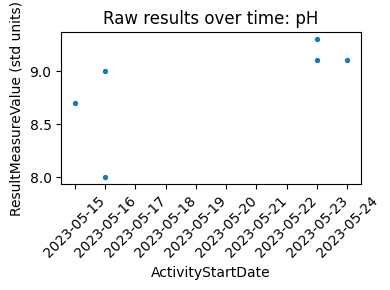

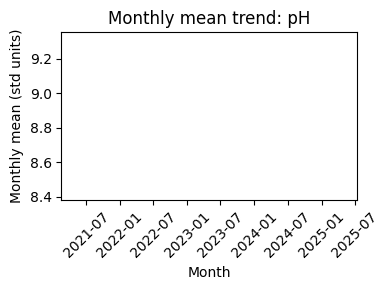

C:\Users\kcui2\AppData\Local\Temp\ipykernel_17780\3692876810.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


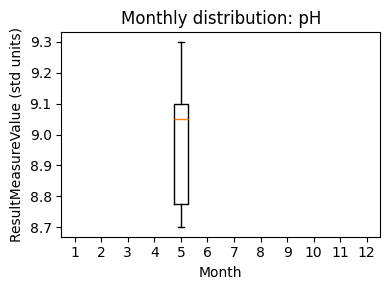

Skipping 'Temperature' (no rows after filtering).
Skipping 'water' (no rows after filtering).
Plotting characteristic: Dissolved oxygen (DO) | unit: mg/L


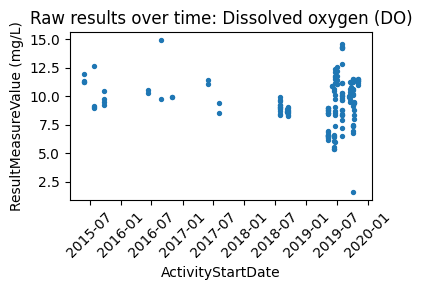

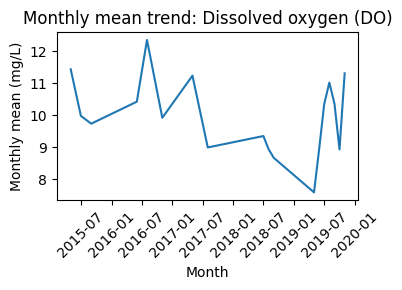

C:\Users\kcui2\AppData\Local\Temp\ipykernel_17780\3692876810.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


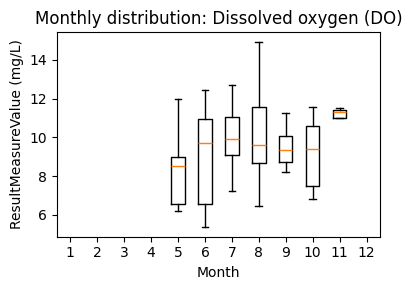

Plotting characteristic: Phosphorus | unit: mg/L


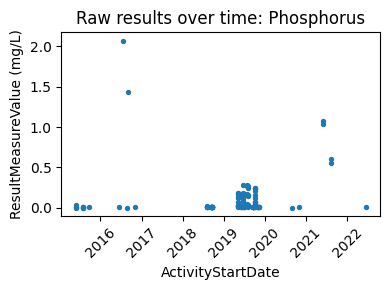

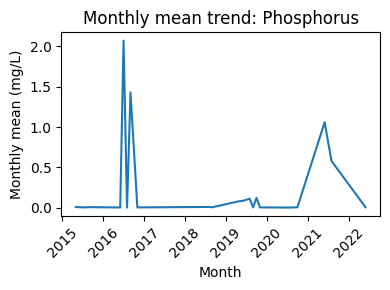

C:\Users\kcui2\AppData\Local\Temp\ipykernel_17780\3692876810.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


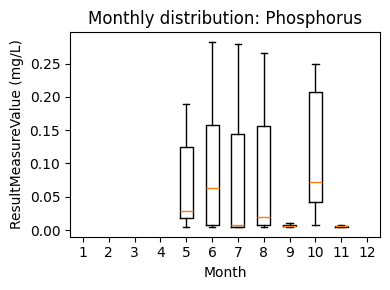

In [ ]:
# chars = ["pH", "Temperature", "water", "Dissolved oxygen (DO)", "Phosphorus"]
chars = ["pH", "Temperature, sample", "Chloride", "Organic carbon", "Alkalinity, total", "Depth, Secci disk depth", "Oxygen", "Total dissolved solids", "Nitrogen", "Flow", "Chlorophyll a", "Phosphorus", "Escherichia coli", "Total suspended solids"]
plot_wqp_characteristic_trends(df_target, chars)


Too sparse